# Adaptive Client-Specific DP for Federated IDS

This notebook:
1. loads the ECU and WUSTL tabular IDS datasets;
2. preprocesses them for binary classification;
3. simulates heterogeneous federated clients with Dirichlet splitting;
4. trains a federated MLP with either fixed or adaptive client-side Gaussian noise;
5. compares results with shared experimental seeds for fair fixed-vs-adaptive comparisons, and;
6. reports tables, plots, and client-level diagnostics.


In [7]:
import copy
import math
import random
from dataclasses import dataclass, replace
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [9]:
@dataclass
class FLConfig:
    # Dataset paths
    ecu_path: str = "data/cleaned_ecu.parquet"
    wustl_path: str = "data/cleaned_wustl.parquet"

    # Data / splitting
    label_col: str = "label"
    test_size: float = 0.2
    n_clients: int = 8
    dirichlet_alpha: float = 0.3
    min_client_size: int = 64

    # Model / local training
    hidden_dim: int = 64
    local_epochs: int = 2
    batch_size: int = 128
    lr: float = 1e-3

    # Federated training
    rounds: int = 25
    clients_per_round: int = 4
    weighted_aggregation: bool = True

    # DP / clipping
    clip_norm: float = 1.0
    base_sigma: float = 0.02
    sigma_min: float = 0.005
    sigma_max: float = 0.10

    # Adaptive sigma controls
    dp_mode: str = "adaptive"  # "fixed" or "adaptive"
    drift_beta: float = 0.75
    imbalance_gamma: float = 1.00
    size_lambda: float = 0.50

    # Reproducibility / logging
    experiment_seed: int = 42
    verbose: bool = True

base_cfg = FLConfig()

In [10]:
base_cfg.ecu_path = "cleaned_ecu.parquet"
base_cfg.wustl_path = "cleaned_wustl.parquet"

ecu_df = pd.read_parquet(base_cfg.ecu_path)
wustl_df = pd.read_parquet(base_cfg.wustl_path)

print("ECU shape:", ecu_df.shape)
print("WUSTL shape:", wustl_df.shape)

ECU shape: (111207, 6)
WUSTL shape: (16318, 43)


In [11]:
def dataset_sanity_checks(df: pd.DataFrame, label_col: str = "label") -> pd.DataFrame:
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    label_counts = df[label_col].value_counts(dropna=False).sort_index()
    missing = df.isna().sum().sort_values(ascending=False)

    summary = pd.DataFrame({
        "n_rows": [len(df)],
        "n_cols": [df.shape[1]],
        "n_missing_total": [int(df.isna().sum().sum())],
        "positive_rate": [float(df[label_col].mean())],
    })

    print("Label counts:")
    print(label_counts)
    print("\nTop missing columns:")
    print(missing.head(10))
    return summary

print("ECU sanity check")
ecu_summary = dataset_sanity_checks(ecu_df, base_cfg.label_col)
display(ecu_summary)

print("\nWUSTL sanity check")
wustl_summary = dataset_sanity_checks(wustl_df, base_cfg.label_col)
display(wustl_summary)

ECU sanity check
Label counts:
label
0    23453
1    87754
Name: count, dtype: int64

Top missing columns:
Time           0
Source         0
Destination    0
Protocol       0
Length         0
label          0
dtype: int64


,n_rows,n_cols,n_missing_total,positive_rate
0,111207,6,0,0.789105



WUSTL sanity check
Label counts:
label
0    14272
1     2046
Name: count, dtype: int64

Top missing columns:
Dir         0
SrcMac      0
TotPkts     0
TotBytes    0
Load        0
Loss        0
pLoss       0
pSrcLoss    0
pDstLoss    0
Rate        0
dtype: int64


,n_rows,n_cols,n_missing_total,positive_rate
0,16318,43,0,0.125383


In [12]:
def load_polars_or_pandas(df_like) -> pd.DataFrame:
    if isinstance(df_like, pl.DataFrame):
        return df_like.to_pandas()
    if isinstance(df_like, pd.DataFrame):
        return df_like.copy()
    raise TypeError("Expected a polars or pandas DataFrame.")


def prepare_binary_tabular_data(
    df_like,
    label_col: str = "label",
    test_size: float = 0.2,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    df = load_polars_or_pandas(df_like)

    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    y = df[label_col].astype(int).to_numpy()
    X_df = df.drop(columns=[label_col]).copy()

    for c in X_df.columns:
        if pd.api.types.is_bool_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(int)

    train_df, test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=test_size, stratify=y, random_state=random_state
    )

    train_df = pd.get_dummies(train_df, dummy_na=True)
    test_df = pd.get_dummies(test_df, dummy_na=True)
    train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

    feature_names = list(train_df.columns)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df.astype(np.float32))
    X_test = scaler.transform(test_df.astype(np.float32))

    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.float32),
        y_test.astype(np.float32),
        feature_names,
    )

In [13]:
def dirichlet_split_indices(
    y: np.ndarray,
    n_clients: int,
    alpha: float = 0.3,
    min_size: int = 64,
    seed: int = 42,
) -> List[np.ndarray]:
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    n_classes = len(np.unique(y))

    while True:
        client_indices = [[] for _ in range(n_clients)]

        for cls in range(n_classes):
            cls_idx = np.where(y == cls)[0]
            rng.shuffle(cls_idx)

            proportions = rng.dirichlet(alpha=np.repeat(alpha, n_clients))
            cuts = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
            split_cls = np.split(cls_idx, cuts)

            for client_id, idx_chunk in enumerate(split_cls):
                client_indices[client_id].extend(idx_chunk.tolist())

        client_indices = [np.array(idx, dtype=int) for idx in client_indices]
        sizes = [len(idx) for idx in client_indices]

        if min(sizes) >= min_size:
            return client_indices


def summarize_clients(y: np.ndarray, client_indices: List[np.ndarray]) -> pd.DataFrame:
    rows = []
    global_pos = float(np.mean(y))
    for cid, idx in enumerate(client_indices):
        yc = y[idx]
        pos_rate = float(np.mean(yc)) if len(yc) > 0 else 0.0
        rows.append({
            "client_id": cid,
            "n_samples": len(idx),
            "pos_rate": pos_rate,
            "imbalance_vs_global": abs(pos_rate - global_pos),
        })
    return pd.DataFrame(rows)

In [14]:
class BinaryMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

In [15]:
def get_model_state(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().clone().cpu() for k, v in model.state_dict().items()}


def set_model_state(model: nn.Module, state: Dict[str, torch.Tensor]) -> None:
    model.load_state_dict(state, strict=True)


def state_sub(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: a[k] - b[k] for k in a.keys()}


def state_add(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: a[k] + b[k] for k in a.keys()}


def state_mul(a: Dict[str, torch.Tensor], scalar: float) -> Dict[str, torch.Tensor]:
    return {k: a[k] * scalar for k in a.keys()}


def state_l2_norm(state: Dict[str, torch.Tensor]) -> float:
    total = 0.0
    for v in state.values():
        total += float(torch.sum(v.float() ** 2))
    return math.sqrt(total)


def clip_state_by_l2(state: Dict[str, torch.Tensor], clip_norm: float) -> Tuple[Dict[str, torch.Tensor], float]:
    norm = state_l2_norm(state)
    if norm <= clip_norm or norm == 0.0:
        return {k: v.clone() for k, v in state.items()}, norm
    scale = clip_norm / norm
    return {k: v * scale for k, v in state.items()}, norm


def add_gaussian_noise_to_state(
    state: Dict[str, torch.Tensor],
    sigma: float,
    clip_norm: float,
    device: torch.device = torch.device("cpu"),
) -> Dict[str, torch.Tensor]:
    noisy = {}
    std = sigma * clip_norm
    for k, v in state.items():
        noise = torch.normal(mean=0.0, std=std, size=v.shape, device=device).cpu()
        noisy[k] = v + noise
    return noisy

In [16]:
def make_client_loader(
    X: np.ndarray,
    y: np.ndarray,
    indices: np.ndarray,
    batch_size: int,
    shuffle: bool = True,
) -> DataLoader:
    Xc = torch.tensor(X[indices], dtype=torch.float32)
    yc = torch.tensor(y[indices], dtype=torch.float32)
    ds = TensorDataset(Xc, yc)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def local_train(
    global_state: Dict[str, torch.Tensor],
    X_train: np.ndarray,
    y_train: np.ndarray,
    client_idx: np.ndarray,
    cfg: FLConfig,
    in_dim: int,
) -> Dict[str, torch.Tensor]:
    model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    set_model_state(model, global_state)

    model.train()
    loader = make_client_loader(X_train, y_train, client_idx, cfg.batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.BCEWithLogitsLoss()

    for _ in range(cfg.local_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    local_state = get_model_state(model)
    delta = state_sub(local_state, global_state)
    return delta


def compute_adaptive_sigma(
    base_sigma: float,
    clip_norm: float,
    raw_delta_norm: float,
    client_n: int,
    mean_client_n: float,
    client_pos_rate: float,
    global_pos_rate: float,
    cfg: FLConfig,
) -> float:
    drift_ratio = raw_delta_norm / max(clip_norm, 1e-12)
    imbalance = abs(client_pos_rate - global_pos_rate)
    size_term = math.sqrt(max(mean_client_n, 1.0) / max(client_n, 1.0))

    sigma = base_sigma * (
        1.0
        + cfg.drift_beta * drift_ratio
        + cfg.imbalance_gamma * imbalance
    ) * (1.0 + cfg.size_lambda * (size_term - 1.0))

    sigma = float(np.clip(sigma, cfg.sigma_min, cfg.sigma_max))
    return sigma

In [17]:
@torch.no_grad()
def evaluate_model(
    state: Dict[str, torch.Tensor],
    X_test: np.ndarray,
    y_test: np.ndarray,
    cfg: FLConfig,
) -> Dict[str, float]:
    model = BinaryMLP(in_dim=X_test.shape[1], hidden_dim=cfg.hidden_dim).to(DEVICE)
    set_model_state(model, state)
    model.eval()

    Xb = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    logits = model(Xb).cpu().numpy()
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    }
    try:
        metrics["auc"] = roc_auc_score(y_test, probs)
    except ValueError:
        metrics["auc"] = np.nan

    return metrics


def federated_train_adaptive_dp(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    client_indices: List[np.ndarray],
    cfg: FLConfig,
) -> Tuple[Dict[str, torch.Tensor], pd.DataFrame, pd.DataFrame]:
    in_dim = X_train.shape[1]
    global_model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    global_state = get_model_state(global_model)

    client_stats = summarize_clients(y_train, client_indices)
    global_pos_rate = float(np.mean(y_train))
    mean_client_n = float(client_stats["n_samples"].mean())

    history_rows = []
    sigma_rows = []

    for rnd in range(1, cfg.rounds + 1):
        chosen = np.random.choice(
            len(client_indices),
            size=min(cfg.clients_per_round, len(client_indices)),
            replace=False,
        )

        client_updates = []
        client_weights = []

        for cid in chosen:
            idx = client_indices[cid]
            client_n = len(idx)
            client_pos = float(np.mean(y_train[idx]))

            raw_delta = local_train(
                global_state=global_state,
                X_train=X_train,
                y_train=y_train,
                client_idx=idx,
                cfg=cfg,
                in_dim=in_dim,
            )

            clipped_delta, raw_norm = clip_state_by_l2(raw_delta, cfg.clip_norm)

            if cfg.dp_mode == "fixed":
                sigma_i = cfg.base_sigma
            elif cfg.dp_mode == "adaptive":
                sigma_i = compute_adaptive_sigma(
                    base_sigma=cfg.base_sigma,
                    clip_norm=cfg.clip_norm,
                    raw_delta_norm=raw_norm,
                    client_n=client_n,
                    mean_client_n=mean_client_n,
                    client_pos_rate=client_pos,
                    global_pos_rate=global_pos_rate,
                    cfg=cfg,
                )
            else:
                raise ValueError("cfg.dp_mode must be 'fixed' or 'adaptive'.")

            noisy_delta = add_gaussian_noise_to_state(
                state=clipped_delta,
                sigma=sigma_i,
                clip_norm=cfg.clip_norm,
                device=DEVICE,
            )

            client_updates.append(noisy_delta)
            client_weights.append(client_n if cfg.weighted_aggregation else 1.0)

            sigma_rows.append({
                "round": rnd,
                "client_id": int(cid),
                "client_n": int(client_n),
                "client_pos_rate": float(client_pos),
                "raw_delta_norm": float(raw_norm),
                "sigma": float(sigma_i),
            })

        total_weight = float(np.sum(client_weights))
        agg_delta = None
        for upd, w in zip(client_updates, client_weights):
            scaled = state_mul(upd, float(w) / total_weight)
            agg_delta = scaled if agg_delta is None else state_add(agg_delta, scaled)

        global_state = state_add(global_state, agg_delta)

        metrics = evaluate_model(global_state, X_test, y_test, cfg)
        history_rows.append({"round": rnd, "mode": cfg.dp_mode, **metrics})

        if cfg.verbose:
            print(
                f"[Round {rnd:02d}] acc={metrics['accuracy']:.4f} "
                f"f1={metrics['f1']:.4f} auc={metrics['auc']:.4f}"
            )

    history_df = pd.DataFrame(history_rows)
    sigma_df = pd.DataFrame(sigma_rows)
    return global_state, history_df, sigma_df

In [18]:
def run_experiment(
    raw_df_like,
    cfg: FLConfig,
    dataset_name: str = "dataset",
) -> Tuple[
    Dict[str, torch.Tensor],
    pd.DataFrame,
    pd.DataFrame,
    List[str],
    List[np.ndarray],
    pd.DataFrame,
]:
    # Reset all RNGs so fixed vs adaptive starts from the same conditions
    set_seed(cfg.experiment_seed)

    X_train, X_test, y_train, y_test, feature_names = prepare_binary_tabular_data(
        raw_df_like,
        label_col=cfg.label_col,
        test_size=cfg.test_size,
        random_state=cfg.experiment_seed,
    )

    client_indices = dirichlet_split_indices(
        y=y_train.astype(int),
        n_clients=cfg.n_clients,
        alpha=cfg.dirichlet_alpha,
        min_size=cfg.min_client_size,
        seed=cfg.experiment_seed,
    )

    client_summary_df = summarize_clients(y_train, client_indices)

    print(f"\n[{dataset_name}]")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    display(client_summary_df.describe(include="all"))

    state, history_df, sigma_df = federated_train_adaptive_dp(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        client_indices=client_indices,
        cfg=cfg,
    )

    return state, history_df, sigma_df, feature_names, client_indices, client_summary_df

In [19]:
cfg_fixed = replace(
    base_cfg,
    n_clients=8,
    dirichlet_alpha=0.3,
    rounds=20,
    clients_per_round=4,
    local_epochs=2,
    batch_size=128,
    lr=1e-3,
    clip_norm=1.0,
    base_sigma=0.02,
    dp_mode="fixed",
    experiment_seed=42,
    verbose=True,
)

cfg_adapt = replace(
    base_cfg,
    n_clients=8,
    dirichlet_alpha=0.3,
    rounds=20,
    clients_per_round=4,
    local_epochs=2,
    batch_size=128,
    lr=1e-3,
    clip_norm=1.0,
    base_sigma=0.02,
    dp_mode="adaptive",
    drift_beta=0.75,
    imbalance_gamma=1.00,
    size_lambda=0.50,
    sigma_min=0.005,
    sigma_max=0.10,
    experiment_seed=42,
    verbose=True,
)

In [20]:
ecu_fixed_state, ecu_fixed_hist, ecu_fixed_sigma, ecu_features, ecu_clients, ecu_fixed_client_summary = run_experiment(
    ecu_df, cfg_fixed, dataset_name="ECU / Fixed DP"
)

ecu_adapt_state, ecu_adapt_hist, ecu_adapt_sigma, _, _, ecu_adapt_client_summary = run_experiment(
    ecu_df, cfg_adapt, dataset_name="ECU / Adaptive DP"
)


[ECU / Fixed DP]
Train shape: (88965, 156), Test shape: (22242, 156)


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.000000,8.000000,8.000000
mean,3.50000,11120.625000,0.574796,0.363726
std,2.44949,12580.653764,0.405071,0.255689
min,0.00000,103.000000,0.016836,0.177458
25%,1.75000,1485.000000,0.301954,0.194767
50%,3.50000,7587.000000,0.594438,0.210795
75%,5.25000,14610.500000,0.982291,0.487154
max,7.00000,32090.000000,0.998816,0.772272


[Round 01] acc=0.9392 f1=0.9601 auc=0.9700
[Round 02] acc=0.9257 f1=0.9506 auc=0.9901
[Round 03] acc=0.9258 f1=0.9507 auc=0.9935
[Round 04] acc=0.9280 f1=0.9522 auc=0.9950
[Round 05] acc=0.9865 f1=0.9914 auc=0.9930
[Round 06] acc=0.9862 f1=0.9912 auc=0.9930
[Round 07] acc=0.9875 f1=0.9921 auc=0.9959
[Round 08] acc=0.9836 f1=0.9897 auc=0.9953
[Round 09] acc=0.9813 f1=0.9882 auc=0.9955
[Round 10] acc=0.9787 f1=0.9866 auc=0.9955
[Round 11] acc=0.9759 f1=0.9849 auc=0.9957
[Round 12] acc=0.9757 f1=0.9848 auc=0.9968
[Round 13] acc=0.9764 f1=0.9852 auc=0.9969
[Round 14] acc=0.9746 f1=0.9841 auc=0.9969
[Round 15] acc=0.9649 f1=0.9782 auc=0.9971
[Round 16] acc=0.9620 f1=0.9764 auc=0.9973
[Round 17] acc=0.9795 f1=0.9871 auc=0.9973
[Round 18] acc=0.9806 f1=0.9878 auc=0.9976
[Round 19] acc=0.9795 f1=0.9871 auc=0.9977
[Round 20] acc=0.9718 f1=0.9824 auc=0.9977

[ECU / Adaptive DP]
Train shape: (88965, 156), Test shape: (22242, 156)


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.000000,8.000000,8.000000
mean,3.50000,11120.625000,0.574796,0.363726
std,2.44949,12580.653764,0.405071,0.255689
min,0.00000,103.000000,0.016836,0.177458
25%,1.75000,1485.000000,0.301954,0.194767
50%,3.50000,7587.000000,0.594438,0.210795
75%,5.25000,14610.500000,0.982291,0.487154
max,7.00000,32090.000000,0.998816,0.772272


[Round 01] acc=0.2364 f1=0.0815 auc=0.9355
[Round 02] acc=0.2086 f1=0.0072 auc=0.9604
[Round 03] acc=0.9070 f1=0.9378 auc=0.9731
[Round 04] acc=0.9464 f1=0.9653 auc=0.9587
[Round 05] acc=0.9455 f1=0.9654 auc=0.9145
[Round 06] acc=0.9024 f1=0.9400 auc=0.8957
[Round 07] acc=0.9170 f1=0.9469 auc=0.9215
[Round 08] acc=0.9419 f1=0.9634 auc=0.9130
[Round 09] acc=0.9014 f1=0.9398 auc=0.8788
[Round 10] acc=0.9505 f1=0.9693 auc=0.8807
[Round 11] acc=0.9459 f1=0.9666 auc=0.9036
[Round 12] acc=0.9572 f1=0.9735 auc=0.9519
[Round 13] acc=0.9650 f1=0.9781 auc=0.9601
[Round 14] acc=0.9608 f1=0.9756 auc=0.9643
[Round 15] acc=0.9642 f1=0.9776 auc=0.9650
[Round 16] acc=0.9608 f1=0.9757 auc=0.9698
[Round 17] acc=0.9620 f1=0.9763 auc=0.9735
[Round 18] acc=0.9655 f1=0.9785 auc=0.9751
[Round 19] acc=0.9639 f1=0.9775 auc=0.9715
[Round 20] acc=0.9095 f1=0.9457 auc=0.9614


In [21]:
wustl_fixed_state, wustl_fixed_hist, wustl_fixed_sigma, wustl_features, wustl_clients, wustl_fixed_client_summary = run_experiment(
    wustl_df, cfg_fixed, dataset_name="WUSTL / Fixed DP"
)

wustl_adapt_state, wustl_adapt_hist, wustl_adapt_sigma, _, _, wustl_adapt_client_summary = run_experiment(
    wustl_df, cfg_adapt, dataset_name="WUSTL / Adaptive DP"
)


[WUSTL / Fixed DP]
Train shape: (13054, 13107), Test shape: (3264, 13107)


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.000000,8.000000,8.000000
mean,3.50000,1631.750000,0.147819,0.148294
std,2.44949,1503.698939,0.229303,0.167397
min,0.00000,203.000000,0.000000,0.037334
25%,1.75000,876.250000,0.000240,0.064740
50%,3.50000,1106.000000,0.061591,0.108215
75%,5.25000,1799.500000,0.176239,0.125402
max,7.00000,4664.000000,0.679563,0.554161


[Round 01] acc=0.8771 f1=0.0520 auc=0.9712
[Round 02] acc=0.8741 f1=0.0048 auc=0.9670
[Round 03] acc=0.8750 f1=0.0286 auc=0.9766
[Round 04] acc=0.8741 f1=0.0144 auc=0.9928
[Round 05] acc=0.8750 f1=0.0286 auc=0.9932
[Round 06] acc=0.8738 f1=0.0096 auc=0.9944
[Round 07] acc=0.8738 f1=0.0096 auc=0.9944
[Round 08] acc=0.8753 f1=0.0286 auc=0.9866
[Round 09] acc=0.8756 f1=0.0287 auc=0.9897
[Round 10] acc=0.8756 f1=0.0287 auc=0.9861
[Round 11] acc=0.8756 f1=0.0287 auc=0.9859
[Round 12] acc=0.8750 f1=0.0192 auc=0.9810
[Round 13] acc=0.8750 f1=0.0192 auc=0.9782
[Round 14] acc=0.8756 f1=0.0240 auc=0.9808
[Round 15] acc=0.8759 f1=0.0288 auc=0.9843
[Round 16] acc=0.8759 f1=0.0288 auc=0.9812
[Round 17] acc=0.8759 f1=0.0288 auc=0.9796
[Round 18] acc=0.8747 f1=0.0097 auc=0.9829
[Round 19] acc=0.8747 f1=0.0097 auc=0.9821
[Round 20] acc=0.8747 f1=0.0097 auc=0.9866

[WUSTL / Adaptive DP]
Train shape: (13054, 13107), Test shape: (3264, 13107)


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.000000,8.000000,8.000000
mean,3.50000,1631.750000,0.147819,0.148294
std,2.44949,1503.698939,0.229303,0.167397
min,0.00000,203.000000,0.000000,0.037334
25%,1.75000,876.250000,0.000240,0.064740
50%,3.50000,1106.000000,0.061591,0.108215
75%,5.25000,1799.500000,0.176239,0.125402
max,7.00000,4664.000000,0.679563,0.554161


[Round 01] acc=0.6026 f1=0.3803 auc=0.9222
[Round 02] acc=0.9323 f1=0.7268 auc=0.9667
[Round 03] acc=0.9350 f1=0.7006 auc=0.9776
[Round 04] acc=0.9332 f1=0.6746 auc=0.9797
[Round 05] acc=0.8992 f1=0.4007 auc=0.9034
[Round 06] acc=0.8704 f1=0.0364 auc=0.8309
[Round 07] acc=0.8713 f1=0.0411 auc=0.7457
[Round 08] acc=0.8704 f1=0.0494 auc=0.7558
[Round 09] acc=0.8707 f1=0.0409 auc=0.5985
[Round 10] acc=0.8701 f1=0.0320 auc=0.7902
[Round 11] acc=0.8719 f1=0.0324 auc=0.5322
[Round 12] acc=0.8719 f1=0.0324 auc=0.4502
[Round 13] acc=0.8725 f1=0.0326 auc=0.6453
[Round 14] acc=0.8725 f1=0.0326 auc=0.6315
[Round 15] acc=0.8756 f1=0.0333 auc=0.3980
[Round 16] acc=0.8759 f1=0.0334 auc=0.4139
[Round 17] acc=0.8759 f1=0.0334 auc=0.4979
[Round 18] acc=0.8759 f1=0.0334 auc=0.5246
[Round 19] acc=0.8744 f1=0.0238 auc=0.7827
[Round 20] acc=0.8722 f1=0.0280 auc=0.7772


In [22]:
def build_results_table(dataset_name: str, hist_fixed: pd.DataFrame, hist_adapt: pd.DataFrame) -> pd.DataFrame:
    fixed_best = hist_fixed.sort_values(["f1", "auc", "accuracy"], ascending=False).iloc[0]
    adapt_best = hist_adapt.sort_values(["f1", "auc", "accuracy"], ascending=False).iloc[0]
    return pd.DataFrame([
        {
            "dataset": dataset_name,
            "mode": "fixed",
            "best_round": int(fixed_best["round"]),
            "accuracy": float(fixed_best["accuracy"]),
            "precision": float(fixed_best["precision"]),
            "recall": float(fixed_best["recall"]),
            "f1": float(fixed_best["f1"]),
            "auc": float(fixed_best["auc"]),
        },
        {
            "dataset": dataset_name,
            "mode": "adaptive",
            "best_round": int(adapt_best["round"]),
            "accuracy": float(adapt_best["accuracy"]),
            "precision": float(adapt_best["precision"]),
            "recall": float(adapt_best["recall"]),
            "f1": float(adapt_best["f1"]),
            "auc": float(adapt_best["auc"]),
        },
    ])

results_table = pd.concat([
    build_results_table("ECU", ecu_fixed_hist, ecu_adapt_hist),
    build_results_table("WUSTL", wustl_fixed_hist, wustl_adapt_hist),
], ignore_index=True)

display(results_table)

,dataset,mode,best_round,accuracy,precision,recall,f1,auc
0,ECU,fixed,7,0.987456,0.992080,0.992023,0.992052,0.995883
1,ECU,adaptive,18,0.965516,0.962115,0.995499,0.978522,0.975068
2,WUSTL,fixed,1,0.877145,0.785714,0.026895,0.052009,0.971163
3,WUSTL,adaptive,2,0.932292,0.735000,0.718826,0.726823,0.966731


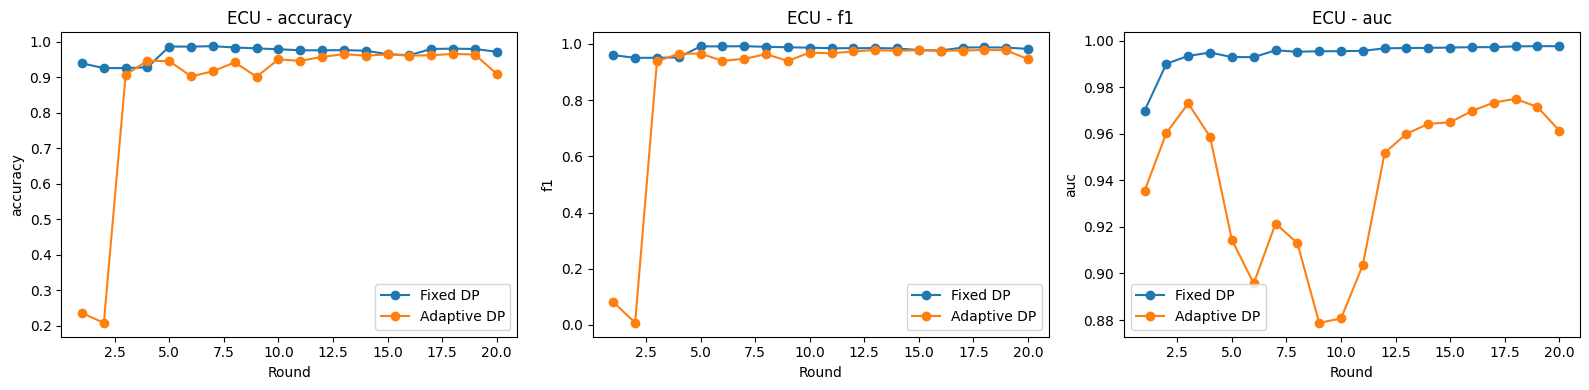

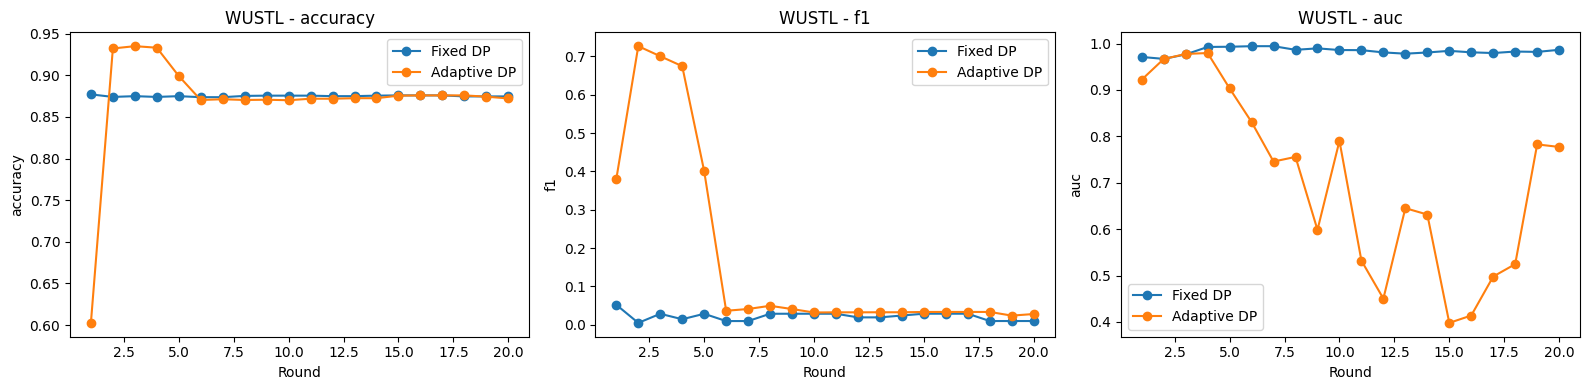

In [23]:
def plot_metric_comparison(hist_fixed: pd.DataFrame, hist_adapt: pd.DataFrame, title: str):
    metrics = ["accuracy", "f1", "auc"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, metric in zip(axes, metrics):
        ax.plot(hist_fixed["round"], hist_fixed[metric], marker="o", label="Fixed DP")
        ax.plot(hist_adapt["round"], hist_adapt[metric], marker="o", label="Adaptive DP")
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("Round")
        ax.set_ylabel(metric)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_metric_comparison(ecu_fixed_hist, ecu_adapt_hist, "ECU")
plot_metric_comparison(wustl_fixed_hist, wustl_adapt_hist, "WUSTL")

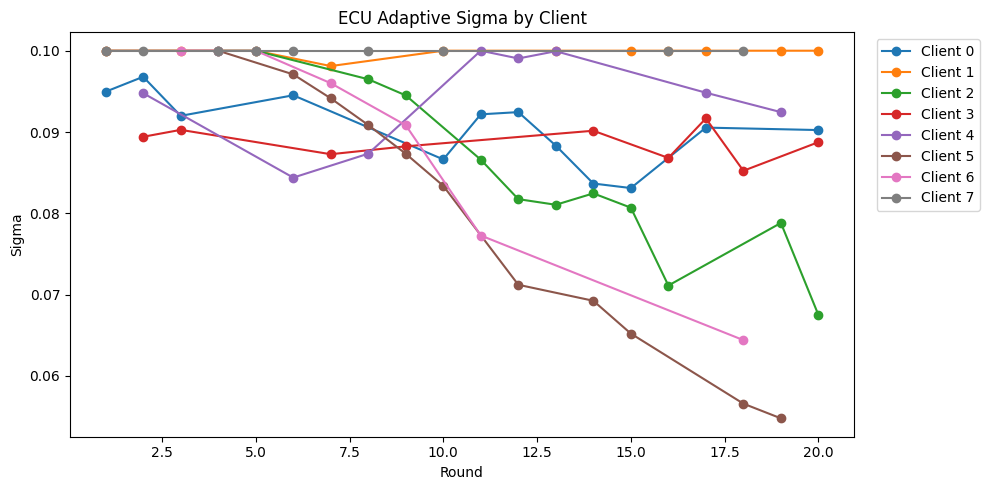

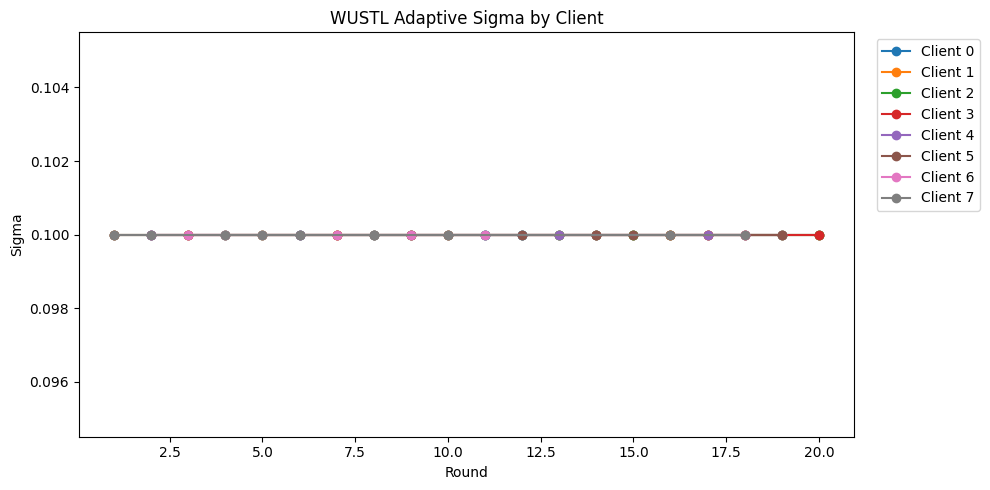

In [24]:
def plot_sigma_history(sigma_df: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 5))
    for cid in sorted(sigma_df["client_id"].unique()):
        sub = sigma_df[sigma_df["client_id"] == cid]
        plt.plot(sub["round"], sub["sigma"], marker="o", label=f"Client {cid}")
    plt.title(title)
    plt.xlabel("Round")
    plt.ylabel("Sigma")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_sigma_history(ecu_adapt_sigma, "ECU Adaptive Sigma by Client")
plot_sigma_history(wustl_adapt_sigma, "WUSTL Adaptive Sigma by Client")

In [25]:
print("ECU client summary")
display(ecu_fixed_client_summary)

print("WUSTL client summary")
display(wustl_fixed_client_summary)

ECU client summary


,client_id,n_samples,pos_rate,imbalance_vs_global
0,0,1651,0.577226,0.211882
1,1,987,0.390071,0.399037
2,2,32090,0.998816,0.209708
3,3,9741,0.016836,0.772272
4,4,7499,0.037605,0.751503
5,5,29219,0.984668,0.195559
6,6,7675,0.981498,0.192390
7,7,103,0.611650,0.177458


WUSTL client summary


,client_id,n_samples,pos_rate,imbalance_vs_global
0,0,203,0.216749,0.091347
1,1,1008,0.679563,0.554161
2,2,1356,0.059735,0.065668
3,3,1156,0.000000,0.125402
4,4,481,0.000000,0.125402
5,5,1056,0.063447,0.061955
6,6,3130,0.000319,0.125083
7,7,4664,0.162736,0.037334
